# Estudo Exploratório: Brent, Macroeconomia e Risco Geopolítico

Este notebook desenvolve a etapa de **análise exploratória de dados (EDA)** do projeto *Geopolitical Fuel Forecast: Estreito de Ormuz*. O foco é entender como o preço do Brent e seu log-retorno se relacionam com variáveis macroeconômicas e com o índice de risco geopolítico construído para o estudo.

## Perguntas que guiam a análise
- Como o Brent evolui ao longo do tempo e quais períodos concentram maior volatilidade?
- Há evidência visual de associação entre Brent, dólar, juros e risco geopolítico?
- O regime geopolítico altera retorno médio, dispersão e assimetria do mercado de petróleo?
- O episódio sintético de Ormuz em 2026 se destaca frente aos demais choques do histórico?

## Observação metodológica importante
Este estudo combina séries observadas com variáveis ainda **simuladas/placeholder** (`oil_production` e `oil_stock`) e um índice de risco geopolítico **construído por eventos**. Portanto, a leitura correta é: o projeto já permite um estudo econométrico consistente de estrutura e narrativa, mas ainda não equivale a uma base puramente observacional.

Esse trecho de script é o ponto de partida da análise exploratória e estatística do seu projeto de previsão de preços de combustível sob risco geopolítico. Ele não executa ainda nenhuma transformação ou modelagem — mas configura todo o ambiente analítico e define a base de dados que será utilizada.
Vou explicar de forma alinhada ao seu estudo (macroeconomia + econometria + séries temporais 👇).

Isso padroniza os gráficos:
- estilo tipo Seaborn (clean + grid) → ideal para séries temporais
- tamanho maior → melhora leitura de tendências
- títulos e labels ajustados → facilita interpretação econômica
👉 Isso é fundamental para:
- visualizar choques (ex: eventos geopolíticos)
- identificar tendências e quebras estruturais
- comparar variáveis (Brent vs combustível)

Aqui você está:
permitindo visualizar muitas colunas (dataset macroeconômico costuma ser largo)
formatando números com 4 casas decimais
👉 Isso é especialmente útil porque:
coeficientes econométricos exigem precisão
pequenas variações percentuais são relevantes no seu estudo

In [2]:
from pathlib import Path # padroniza caminhos de arquivos (portável entre sistemas)

import numpy as np # operações numéricas vetorizadas
import pandas as pd # manipulação de dados tabulares (DataFrame)
import matplotlib.pyplot as plt # visualização de séries temporais
from scipy import stats # testes estatísticos (correlação, normalidade, etc.)

plt.style.use('seaborn-v0_8-whitegrid') # estilo tipo Seaborn (clean + grid) → ideal para séries temporais
plt.rcParams['figure.figsize'] = (12, 6) # tamanho padrão das figuras (largura x altura) em polegadas
plt.rcParams['axes.titlesize'] = 14 # tamanho do título dos gráficos
plt.rcParams['axes.labelsize'] = 11 # tamanho dos rótulos dos eixos
pd.set_option('display.max_columns', 100) # mostra todas as colunas do DataFrame ao imprimir (evita truncamento)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}') # formata números decimais com 4 casas e separador de milhar (ex: 1,234.5678)

DATA_PATH = Path('../data/processed/fuel_dataset.csv') # caminho para o dataset processado (ajuste conforme necessário)

In [3]:
df = pd.read_csv(DATA_PATH, parse_dates=['Date']).sort_values('Date').reset_index(drop=True) # lê o dataset, converte a coluna 'Date' para datetime, ordena por data e reseta o índice
df['brent_return_pct'] = df['brent_log_return'] * 100 # converte log return para percentual (ex: 0.01 → 1.00%)

# Classificação de risco geopolítico em regimes (Baixo, Médio, Alto) com base nos quantis da coluna 'geopolitical_risk'
def classify_risk(x):
    if x <= df['geopolitical_risk'].quantile(0.33):
        return 'Baixo'
    if x <= df['geopolitical_risk'].quantile(0.66):
        return 'Médio'
    return 'Alto'

# Aplica a função de classificação à coluna 'geopolitical_risk' e cria uma nova coluna 'risk_regime' com os regimes de risco correspondentes
df['risk_regime'] = df['geopolitical_risk'].apply(classify_risk)

# Auditoria de dados: tipo, contagem e porcentagem de valores ausentes por coluna
audit = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing': df.isna().sum(),
    'missing_%': (df.isna().mean() * 100).round(2),
})

# Resumo do dataset: período coberto, número de observações e auditoria de dados
print(f'Período analisado: {df.Date.min().date()} até {df.Date.max().date()}')
print(f'Observações mensais: {len(df)}')
audit

Período analisado: 2007-07-31 até 2026-03-31
Observações mensais: 225


,dtype,missing,missing_%
Date,datetime64[us],0,0.0000
brent_price,float64,0,0.0000
brent_log_return,float64,1,0.4400
usd_index,float64,0,0.0000
interest_rate,float64,1,0.4400
oil_production,float64,0,0.0000
oil_stock,float64,0,0.0000
geopolitical_risk,float64,0,0.0000
ormuz_dummy,int64,0,0.0000
brent_return_pct,float64,1,0.4400


## Leitura econômica da base
A variável dependente de maior interesse para modelagem é o `brent_log_return`, pois ela aproxima variação percentual e reduz o risco de regressões espúrias em nível. Já o `brent_price` continua útil para interpretação econômica, comunicação executiva e leitura de regimes.

As variáveis explicativas representam três blocos:
1. **Preço e condições financeiras globais**: `usd_index` e `interest_rate`.
2. **Oferta de petróleo**: `oil_production` e `oil_stock`.
3. **Choque geopolítico**: `geopolitical_risk` e `ormuz_dummy`.

Essa separação é importante porque, do ponto de vista macroeconômico, o petróleo responde simultaneamente a custo do dólar, liquidez/juros, fundamentos de oferta e prêmios de risco relacionados à segurança energética.



In [4]:
# Estatísticas descritivas para as principais variáveis numéricas (preço do Brent, retorno logarítmico, índice do dólar, taxa de juros, 
# produção e estoque de petróleo, risco geopolítico)
desc = df[['brent_price', 'brent_log_return', 'usd_index', 'interest_rate',
           'oil_production', 'oil_stock', 'geopolitical_risk']].describe().T

# Cálculo de skewness (assimetria) e kurtosis (achatamento) para cada variável numérica e adição ao DataFrame de estatísticas descritivas
desc['skewness'] = df[desc.index].skew(numeric_only=True) 
desc['kurtosis'] = df[desc.index].kurtosis(numeric_only=True)
desc.sort_values('std', ascending=False)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
brent_price,225.0000,78.0943,23.6160,26.6314,62.2279,75.3770,96.7863,134.0995,0.1967,-0.7989
usd_index,225.0000,90.9356,10.0478,72.1168,80.7786,93.4371,98.3610,111.9414,-0.1432,-1.2315
oil_production,225.0000,99.4878,4.6015,88.6213,96.8411,99.0798,102.8020,112.2178,0.1864,-0.2358
oil_stock,225.0000,49.9994,3.0594,41.0831,47.7709,50.0338,52.1975,57.3097,-0.0315,-0.4450
interest_rate,224.0000,1.4860,1.8221,0.0500,0.1100,0.3650,2.3925,5.3300,1.0444,-0.4403
geopolitical_risk,225.0000,-0.0000,1.0000,-0.5742,-0.5742,-0.5742,0.3131,2.5315,1.4971,0.8263
brent_log_return,224.0000,0.0010,0.0924,-0.4955,-0.0466,0.0100,0.0619,0.3156,-1.0671,4.5601


A análise apresentada corresponde à etapa clássica de **estatística descritiva exploratória (Exploratory Data Analysis – EDA)** aplicada a séries temporais macroeconômicas e financeiras. O objetivo central aqui é caracterizar a distribuição, dispersão e propriedades estatísticas das variáveis antes da modelagem econométrica, o que é fundamental para evitar especificações incorretas e inferências enviesadas.

O script constrói uma matriz de estatísticas descritivas a partir das principais variáveis do modelo — preço do Brent, retornos logarítmicos, índice do dólar, taxa de juros, produção e estoques de petróleo e risco geopolítico — utilizando medidas de tendência central, dispersão e momentos de ordem superior (assimetria e curtose). Em seguida, ordena essas variáveis pela volatilidade (desvio padrão), permitindo identificar quais séries apresentam maior instabilidade ao longo do tempo.

Do ponto de vista metodológico, essa abordagem está alinhada com práticas padrão em econometria de séries temporais, nas quais a análise dos momentos da distribuição fornece indícios sobre estacionariedade, presença de caudas pesadas, assimetrias e possíveis regimes distintos de comportamento.

Observa-se, inicialmente, que o preço do Brent apresenta média de aproximadamente 78 USD, com desvio padrão de 23,6, indicando volatilidade relevante ao longo do período analisado (2007–2026). A assimetria levemente positiva (0,19) sugere uma distribuição relativamente equilibrada, enquanto a curtose negativa (-0,79) indica uma distribuição mais achatada que a normal (platocúrtica), sugerindo menor concentração de eventos extremos do que se poderia esperar em uma distribuição normal. Isso é consistente com uma série em nível, que tende a suavizar choques ao longo do tempo.

Em contraste, os retornos logarítmicos do Brent apresentam comportamento estatisticamente distinto. O desvio padrão de 9,24% ao mês evidencia elevada volatilidade, característica típica de séries financeiras. A assimetria negativa (-1,07) indica predominância de choques negativos mais intensos, enquanto a curtose elevada (4,56) revela a presença de caudas pesadas (leptocurtose), ou seja, maior probabilidade de eventos extremos. Esse resultado é crucial do ponto de vista econométrico, pois invalida a hipótese de normalidade dos resíduos e sugere a necessidade de modelos robustos, como GARCH ou regressões com erros heterocedásticos.

O índice do dólar (USD Index) apresenta volatilidade moderada (desvio padrão de aproximadamente 10), com leve assimetria negativa e curtose negativa, indicando uma distribuição relativamente estável e sem presença significativa de outliers. Isso sugere que o canal cambial atua como um fator macroeconômico mais previsível, embora ainda relevante na determinação do preço do petróleo.

A variável de taxa de juros apresenta um comportamento altamente assimétrico (skewness de 1,04), refletindo períodos prolongados de juros baixos intercalados com episódios de elevação mais abrupta. Esse padrão é típico de políticas monetárias assimétricas, especialmente em economias desenvolvidas após crises financeiras. A curtose negativa sugere ausência de extremos frequentes, mas a assimetria indica que choques de alta são mais pronunciados do que reduções.

As variáveis estruturais do mercado de petróleo — produção e estoques — apresentam baixa volatilidade e distribuições próximas da normalidade (baixa assimetria e curtose próxima de zero). Isso é consistente com a natureza dessas variáveis, que são rigidamente controladas e ajustadas de forma gradual por agentes institucionais (como a OPEP e reservas estratégicas). Em termos econométricos, isso sugere que essas variáveis atuam como fatores de tendência (drivers estruturais), enquanto preços e retornos capturam choques de curto prazo.

A variável de risco geopolítico se destaca por apresentar elevada assimetria (1,49) e curtose positiva (0,83), indicando concentração de valores baixos com episódios esporádicos de picos elevados. Esse comportamento é típico de variáveis de risco, que permanecem estáveis na maior parte do tempo, mas apresentam explosões em períodos de crise. Esse padrão reforça a hipótese central do estudo: eventos geopolíticos são raros, porém altamente impactantes, o que justifica a inclusão de uma dummy (ormuz_dummy) para capturar efeitos não lineares.

Outro ponto metodológico relevante é a presença de valores ausentes apenas nos retornos e na taxa de juros (aproximadamente 0,44%), o que é esperado devido à construção de retornos (perda da primeira observação) e eventuais falhas de registro. A baixa proporção de missing values indica boa qualidade dos dados e reduz a necessidade de imputações complexas.

A ordenação das variáveis pelo desvio padrão permite uma leitura clara da hierarquia de volatilidade no sistema: retornos do Brent são os mais voláteis, seguidos pelo preço em nível, pelo índice do dólar e, por fim, pelas variáveis estruturais (produção e estoques). Essa hierarquia é consistente com a literatura econômica, onde preços financeiros ajustam rapidamente a choques, enquanto quantidades físicas se ajustam de forma mais lenta.

Em termos de implicações para a modelagem, os resultados sugerem fortemente que:

1. A modelagem deve ser conduzida preferencialmente em retornos (ou variações percentuais), devido à não estacionariedade potencial dos níveis.
2. A presença de caudas pesadas exige cuidado com hipóteses de normalidade.
3. A inclusão de variáveis geopolíticas é justificada não apenas teoricamente, mas também empiricamente, dada sua distribuição altamente assimétrica.
4. Pode haver ganhos ao incorporar modelos não lineares ou regimes (como Markov Switching ou variáveis dummy), dado o comportamento distinto em períodos de crise.

Em síntese, essa etapa confirma que o sistema analisado possui características típicas de mercados financeiros influenciados por choques exógenos: alta volatilidade nos preços, estabilidade nas variáveis estruturais e forte assimetria em fatores de risco. Isso fornece base empírica sólida para avançar para a modelagem econométrica proposta no estudo.

### Skewness (Assimetria)

O **skewness** mede o grau de assimetria de uma distribuição em relação à sua média. Em termos formais, trata-se do terceiro momento central padronizado da distribuição. Essa métrica indica se os dados estão concentrados mais à esquerda ou à direita.

* **Skewness = 0** → distribuição simétrica (ex: normal)
* **Skewness > 0 (assimetria positiva)** → cauda mais longa à direita

  * poucos valores muito altos (outliers positivos)
  * média > mediana
* **Skewness < 0 (assimetria negativa)** → cauda mais longa à esquerda

  * poucos valores muito baixos (outliers negativos)
  * média < mediana

#### Interpretação no contexto econômico

Em séries financeiras, como retornos do petróleo:

* Assimetria **negativa** (como no `brent_log_return`) indica que **quedas bruscas são mais intensas ou frequentes que altas**, refletindo comportamento típico de mercados sob risco.
* Assimetria **positiva** (como em `geopolitical_risk`) sugere **eventos raros porém extremos**, compatíveis com choques geopolíticos.

---

### Kurtosis (Curtose)

A **kurtosis** mede o grau de concentração dos dados nas caudas da distribuição, ou seja, a propensão a eventos extremos. É o quarto momento central padronizado.

* **Kurtosis = 0** → distribuição normal (mesocúrtica, padrão Gaussiano)
* **Kurtosis > 0 (leptocúrtica)** → caudas pesadas

  * maior probabilidade de eventos extremos (outliers)
* **Kurtosis < 0 (platicúrtica)** → distribuição mais “achatada”

  * menor concentração nas caudas

#### Interpretação no contexto econômico

* A curtose elevada (como no `brent_log_return`, ~4.56) indica que o mercado apresenta **fat tails**, ou seja, choques extremos ocorrem com mais frequência do que o previsto por uma distribuição normal.
* Curtose negativa (como no `brent_price`) sugere uma série mais estável, com menor ocorrência de extremos — típico de variáveis em nível.

---

### Importância Econométrica

A análise conjunta de skewness e kurtosis é fundamental porque:

* Permite verificar **violação da normalidade**, hipótese comum em modelos clássicos (OLS).
* Indica a necessidade de:

  * modelos robustos (ex: erros robustos)
  * modelagem de volatilidade (ex: GARCH)
  * transformações (log, diferenças)
* Ajuda a identificar **assimetria de risco**, especialmente relevante em estudos geopolíticos.

---

### Síntese Intuitiva

* **Skewness → direção do risco (para onde a cauda aponta)**
* **Kurtosis → intensidade do risco (quão pesadas são as caudas)**

No seu estudo, isso reforça um ponto central:

> O mercado de petróleo não é bem descrito por distribuições normais — ele é assimétrico e sujeito a eventos extremos, especialmente em períodos de crise geopolítico.



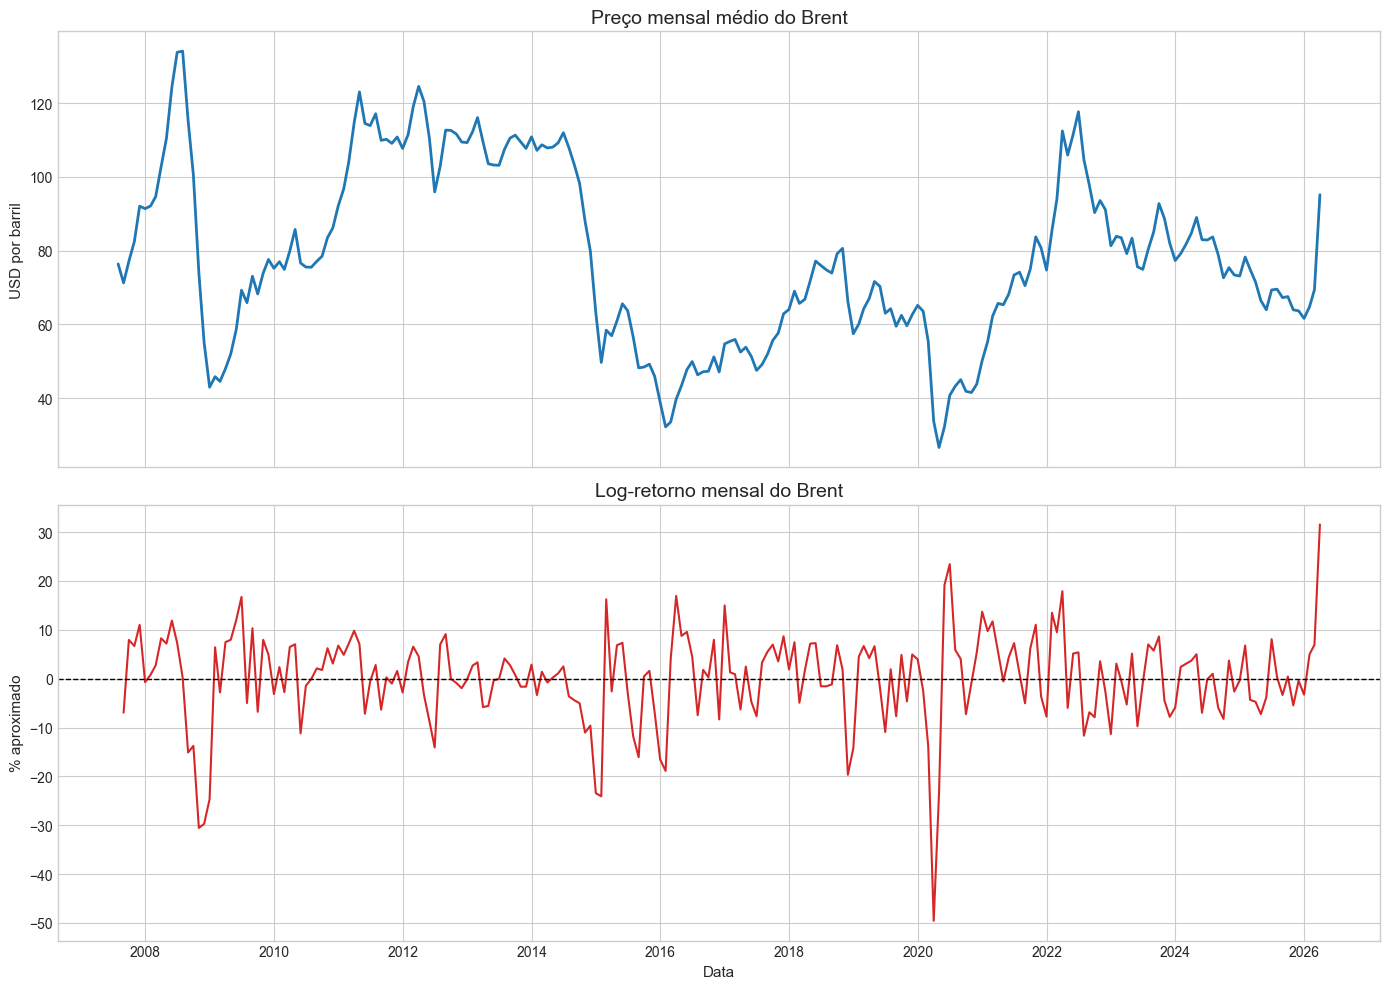

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True) # cria uma figura com 2 subplots verticais (1 coluna, 2 linhas), compartilhando o eixo x (data)

# Gráfico 1: Preço mensal médio do Brent ao longo do tempo
axes[0].plot(df['Date'], df['brent_price'], color='tab:blue', linewidth=2) # linha azul para o preço do Brent
axes[0].set_title('Preço mensal médio do Brent') # título do gráfico
axes[0].set_ylabel('USD por barril') # rótulo do eixo y

# Gráfico 2: Log-retorno mensal do Brent ao longo do tempo (convertido para percentual)
axes[1].plot(df['Date'], df['brent_return_pct'], color='tab:red', linewidth=1.5) # linha vermelha para o retorno percentual do Brent
axes[1].axhline(0, color='black', linestyle='--', linewidth=1) # linha horizontal preta tracejada no nível 0 para referência (sem retorno)
axes[1].set_title('Log-retorno mensal do Brent') # título do gráfico
axes[1].set_ylabel('% aproximado') # rótulo do eixo y (percentual aproximado)
axes[1].set_xlabel('Data') # rótulo do eixo x (data)

# Ajusta o layout para evitar sobreposição de elementos e exibe os gráficos
plt.tight_layout()
plt.show()

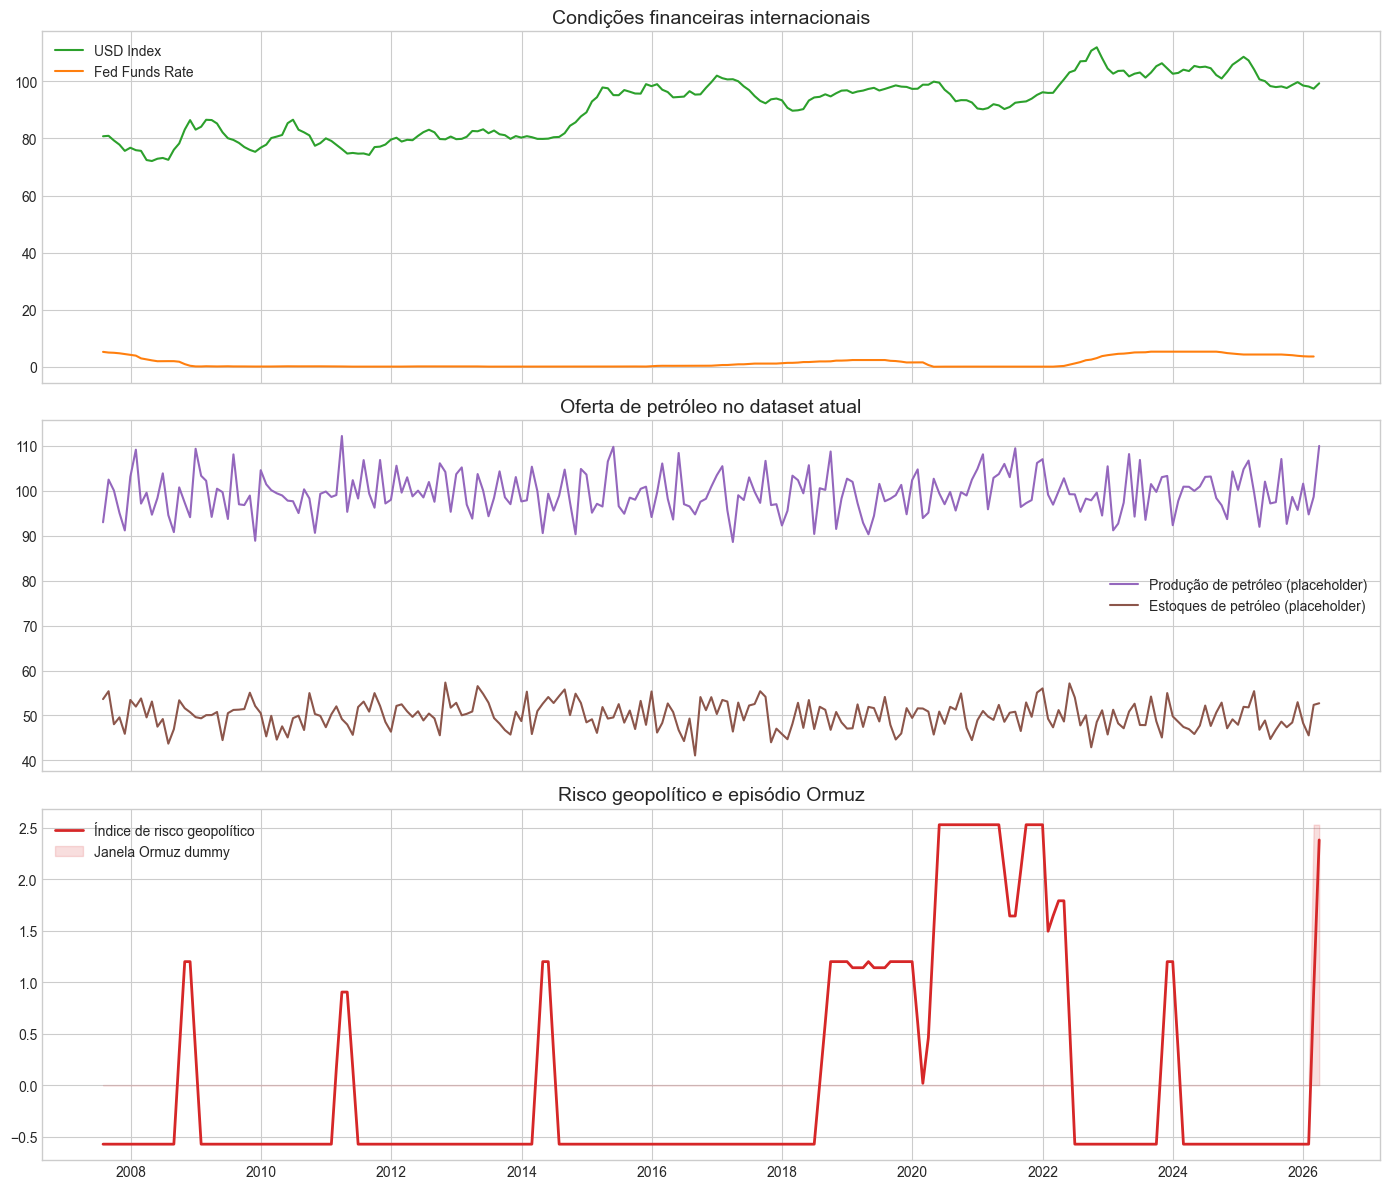

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True) # cria uma figura com 3 subplots verticais (1 coluna, 3 linhas), compartilhando o eixo x (data)

# Gráfico 1: Condições financeiras internacionais (índice do dólar e taxa de juros)
axes[0].plot(df['Date'], df['usd_index'], label='USD Index', color='tab:green')
axes[0].plot(df['Date'], df['interest_rate'], label='Fed Funds Rate', color='tab:orange')
axes[0].set_title('Condições financeiras internacionais')
axes[0].legend()

# Gráfico 2: Oferta de petróleo (produção e estoques) - placeholders para variáveis reais
axes[1].plot(df['Date'], df['oil_production'], label='Produção de petróleo (placeholder)', color='tab:purple')
axes[1].plot(df['Date'], df['oil_stock'], label='Estoques de petróleo (placeholder)', color='tab:brown')
axes[1].set_title('Oferta de petróleo no dataset atual')
axes[1].legend()

# Gráfico 3: Risco geopolítico e episódio Ormuz (com destaque para a janela dummy)
axes[2].plot(df['Date'], df['geopolitical_risk'], label='Índice de risco geopolítico', color='tab:red', linewidth=2)
axes[2].fill_between(df['Date'], 0, df['ormuz_dummy'] * df['geopolitical_risk'].max(),
                     color='tab:red', alpha=0.15, label='Janela Ormuz dummy')
axes[2].set_title('Risco geopolítico e episódio Ormuz')
axes[2].legend()

# Ajusta o layout para evitar sobreposição de elementos e exibe os gráficos
plt.tight_layout()
plt.show()

## Dependência temporal e distribuição
Mercados de petróleo costumam apresentar leptocurtose e volatilidade agrupada. Em uma inspeção preliminar, queremos verificar se os retornos do Brent estão centrados perto de zero, mas com caudas pesadas, e se a dispersão aumenta em momentos de estresse geopolítico.

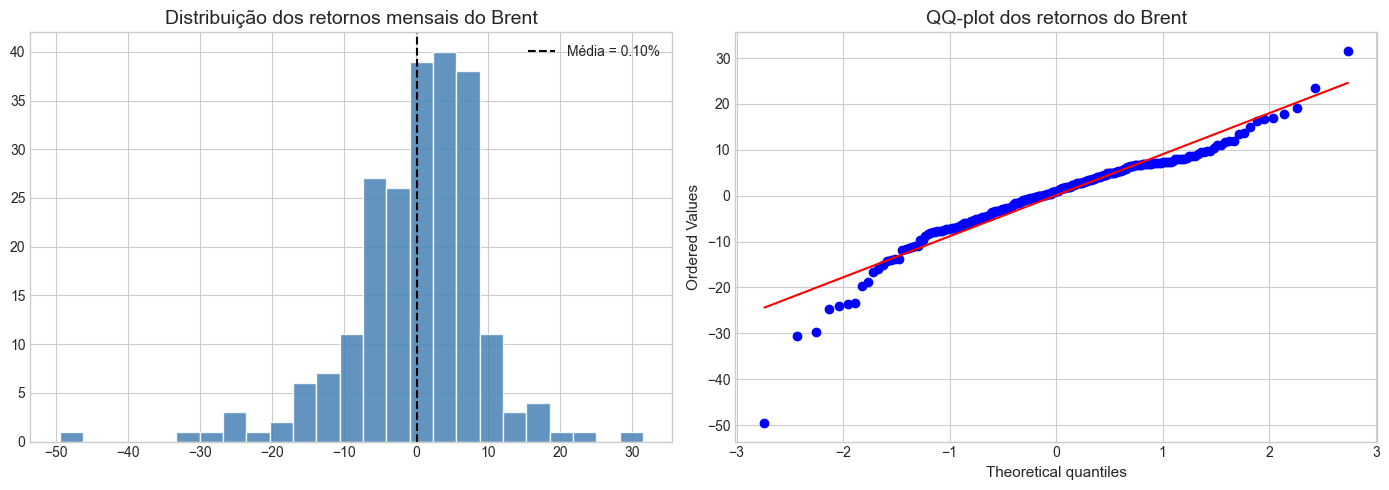

Teste Jarque-Bera: SignificanceResult(statistic=np.float64(225.2928208461104), pvalue=np.float64(1.197527642630789e-49))
Teste Shapiro-Wilk: ShapiroResult(statistic=np.float64(0.9304714634082418), pvalue=np.float64(8.41654635858047e-09))


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5)) # cria uma figura com 1 linha e 2 colunas para os gráficos de distribuição e QQ-plot

# Gráfico 1: Histograma dos retornos mensais do Brent (em percentual)
valid_returns = df['brent_return_pct'].dropna() # remove valores ausentes para evitar erros no histograma e QQ-plot
axes[0].hist(valid_returns, bins=25, color='steelblue', edgecolor='white', alpha=0.85) # histograma com 25 bins, cor azul aço, bordas brancas e leve transparência
axes[0].axvline(valid_returns.mean(), 
                color='black', 
                linestyle='--', 
                label=f'Média = {valid_returns.mean():.2f}%') # linha vertical para a média dos retornos, com rótulo indicando o valor
axes[0].set_title('Distribuição dos retornos mensais do Brent') # título do gráfico
axes[0].legend() # legenda para a linha da média

# Gráfico 2: QQ-plot para verificar a normalidade dos retornos do Brent
stats.probplot(valid_returns, dist='norm', plot=axes[1])
axes[1].set_title('QQ-plot dos retornos do Brent')

# Ajusta o layout para evitar sobreposição de elementos e exibe os gráficos
plt.tight_layout()
plt.show()

# Teste de normalidade de Jarque-Bera para os retornos mensais do Brent
print('Teste Jarque-Bera:', stats.jarque_bera(valid_returns))
# Teste de normalidade de Shapiro-Wilk para os retornos mensais do Brent
print('Teste Shapiro-Wilk:', stats.shapiro(valid_returns))

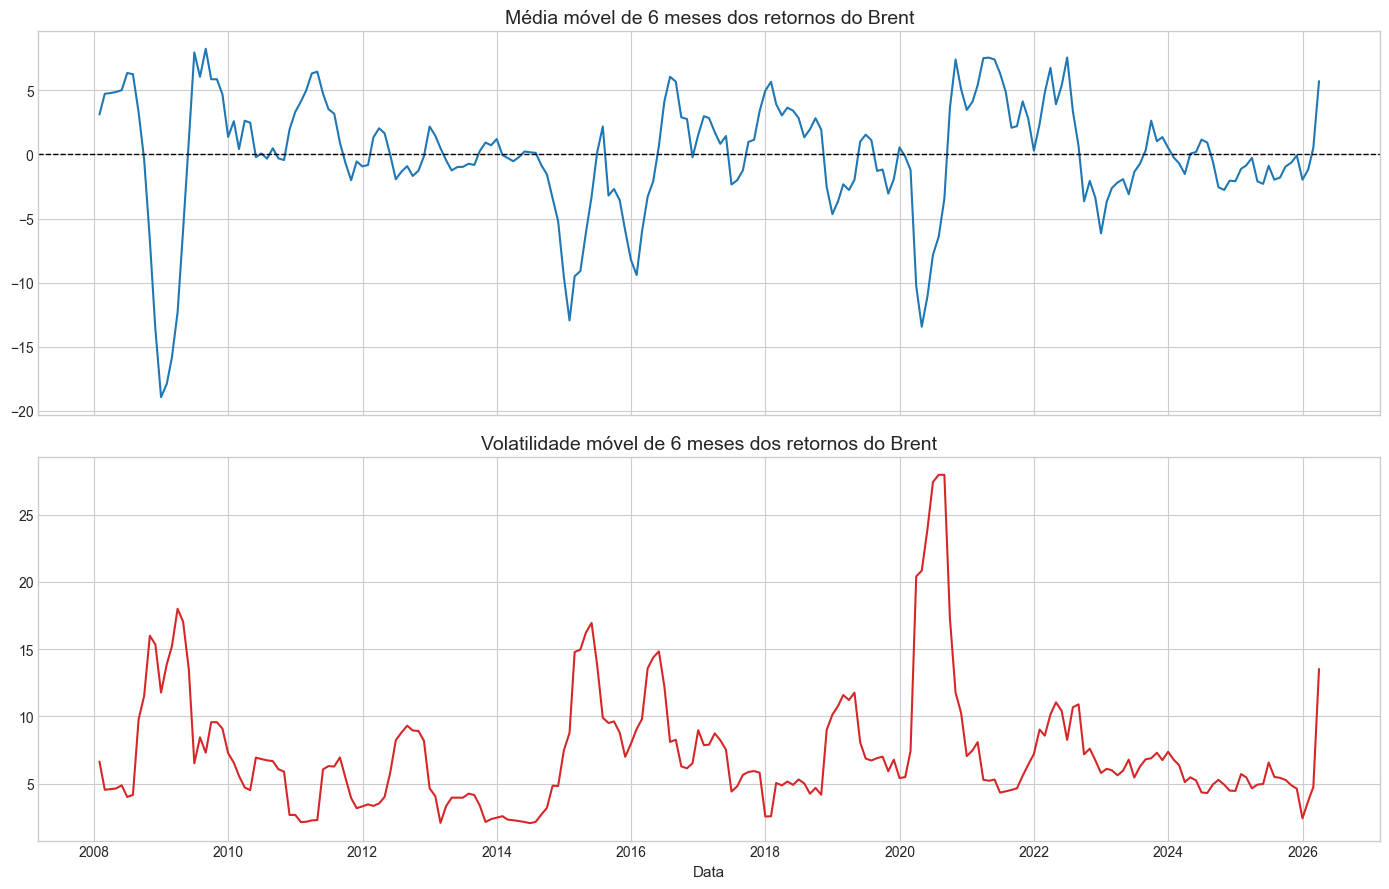

In [ ]:
# Cálculo da volatilidade (desvio padrão) e média móvel de 6 meses dos retornos do Brent para análise de tendências e 
# estabilidade ao longo do tempo
rolling_vol = df['brent_return_pct'].rolling(6).std() # volatilidade móvel de 6 meses (desvio padrão) dos retornos do Brent
rolling_mean = df['brent_return_pct'].rolling(6).mean() # média móvel de 6 meses dos retornos do Brent

# Visualização da média móvel e volatilidade móvel dos retornos do Brent ao longo do tempo
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True) # cria uma figura com 2 subplots verticais (1 coluna, 2 linhas), compartilhando o eixo x (data)
axes[0].plot(df['Date'], rolling_mean, color='tab:blue') # linha azul para a média móvel dos retornos do Brent
axes[0].axhline(0, color='black', linestyle='--', linewidth=1) # linha horizontal preta tracejada no nível 0 para referência (sem retorno)
axes[0].set_title('Média móvel de 6 meses dos retornos do Brent') # título do gráfico

# Gráfico 2: Volatilidade móvel de 6 meses dos retornos do Brent
axes[1].plot(df['Date'], rolling_vol, color='tab:red') # linha vermelha para a volatilidade móvel dos retornos do Brent
axes[1].set_title('Volatilidade móvel de 6 meses dos retornos do Brent') # título do gráfico
axes[1].set_xlabel('Data') # rótulo do eixo x (data)

# Ajusta o layout para evitar sobreposição de elementos e exibe os gráficos
plt.tight_layout() 
plt.show()

## Correlações e relações bivariadas
Correlação não implica causalidade, mas ajuda a localizar combinações promissoras para o modelo econométrico. Em especial, o petróleo costuma reagir a:
- fortalecimento do dólar, por canal de preço relativo internacional;
- mudanças em juros, por canal de ciclo e liquidez;
- choques geopolíticos, por canal de prêmio de risco e restrição esperada de oferta.

In [ ]:
# Cálculo das correlações de Pearson e Spearman entre o log
features = ['brent_log_return', 'brent_price', 'usd_index', 'interest_rate',
            'oil_production', 'oil_stock', 'geopolitical_risk', 'ormuz_dummy'] # lista de variáveis para calcular as correlações
pearson_corr = df[features].corr(method='pearson') # correlação de Pearson (linear) entre as variáveis selecionadas
spearman_corr = df[features].corr(method='spearman') # correlação de Spearman (rank-based) entre as variáveis selecionadas

# Exibição das correlações de Pearson e Spearman com o log-retorno do Brent, ordenadas do mais positivo para o mais negativo
print('Correlação de Pearson com o log-retorno do Brent') 
display(pearson_corr[['brent_log_return']].sort_values('brent_log_return', ascending=False)) # exibe a correlação de Pearson com o log-retorno do Brent, ordenada do mais positivo para o mais negativo

# Exibição da correlação de Spearman com o log-retorno do Brent, ordenada do mais positivo para o mais negativo
print('Correlação de Spearman com o log-retorno do Brent')
display(spearman_corr[['brent_log_return']].sort_values('brent_log_return', ascending=False)) # exibe a correlação de Spearman com o log-retorno do Brent, ordenada do mais positivo para o mais negativo

Correlação de Pearson com o log-retorno do Brent


,brent_log_return
brent_log_return,1.0000
ormuz_dummy,0.1971
brent_price,0.1302
geopolitical_risk,0.1031
oil_production,0.0770
interest_rate,-0.0303
oil_stock,-0.0351
usd_index,-0.0818


Correlação de Spearman com o log-retorno do Brent


,brent_log_return
brent_log_return,1.0000
ormuz_dummy,0.1314
geopolitical_risk,0.0648
brent_price,0.0526
oil_production,0.0210
oil_stock,-0.0620
interest_rate,-0.0704
usd_index,-0.1522


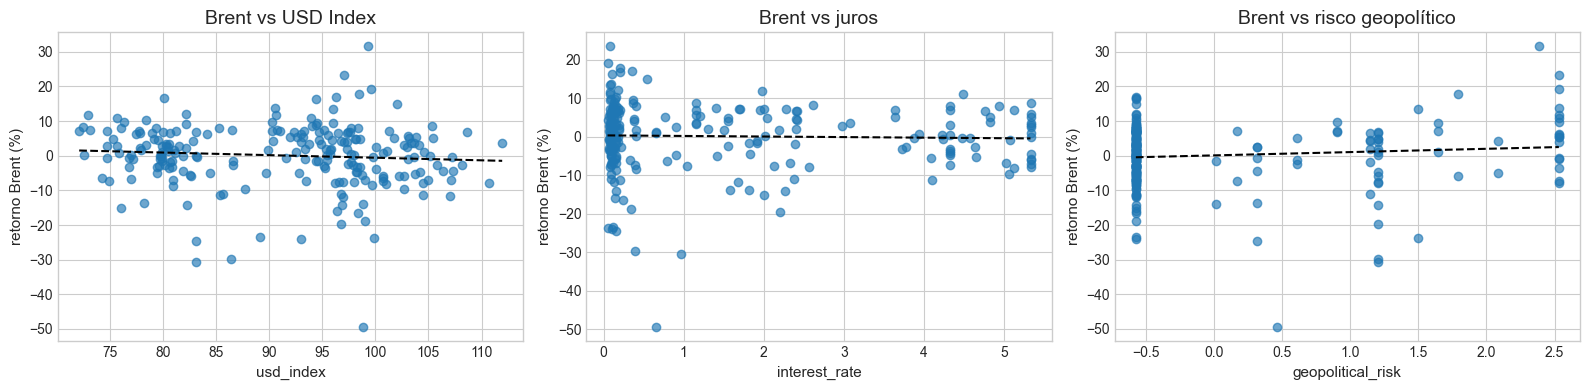

In [ ]:
# Visualização de dispersão (scatter plots) para as variáveis com maior correlação (positiva ou negativa) 
# com os retornos do Brent, incluindo uma linha de tendência linear para destacar a relação
pairs = [
    ('usd_index', 'Brent vs USD Index'),
    ('interest_rate', 'Brent vs juros'),
    ('geopolitical_risk', 'Brent vs risco geopolítico'),
] # lista de pares de variáveis para plotar (coluna do DataFrame, título do gráfico)

# Criação de subplots para cada par de variáveis, com scatter plot e linha de tendência linear
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
# Para cada par de variável e título, cria um scatter plot dos valores da variável contra os retornos do Brent, 
# calcula a linha de tendência linear (regressão) e a plota no gráfico, além de configurar títulos e rótulos dos eixos
for ax, (col, title) in zip(axes, pairs):
    ax.scatter(df[col], df['brent_return_pct'], alpha=0.65) # scatter plot dos valores da variável contra os retornos do Brent, com leve transparência (alpha=0.65)
    z = np.polyfit(df[col].fillna(df[col].mean()), df['brent_return_pct'].fillna(0), 1) # cálculo da linha de tendência linear (regressão) usando np.polyfit, preenchendo valores ausentes com a média da variável e 0 para os retornos
    xs = np.linspace(df[col].min(), df[col].max(), 100) # gera 100 pontos igualmente espaçados entre o mínimo e máximo da variável para plotar a linha de tendência
    ax.plot(xs, z[0] * xs + z[1], color='black', linestyle='--') # plota a linha de tendência linear no gráfico, com cor preta e estilo tracejado
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel('retorno Brent (%)')
plt.tight_layout()
plt.show()

## Regimes geopolíticos
Uma leitura útil para geoeconomia é comparar o mercado em regimes de risco. Em vez de olhar só para média, avaliamos também volatilidade, quartis e proporção de meses com retorno positivo.

In [ ]:
# Análise de regimes de risco geopolítico: cálculo de estatísticas descritivas para os retornos do Brent em 
# cada regime (Baixo, Médio, Alto)
regime_stats = df.groupby('risk_regime')['brent_return_pct'].agg([
    ('observacoes', 'count'),
    ('media_pct', 'mean'),
    ('mediana_pct', 'median'),
    ('volatilidade_pct', 'std'),
    ('q25', lambda s: s.quantile(0.25)),
    ('q75', lambda s: s.quantile(0.75)),
    ('share_positivo', lambda s: (s > 0).mean()),
]).sort_values('volatilidade_pct', ascending=False)
regime_stats

,observacoes,media_pct,mediana_pct,volatilidade_pct,q25,q75,share_positivo
risk_regime,,,,,,,
Alto,65,-0.2748,1.9143,12.9699,-5.9053,6.6817,0.5692
Baixo,159,0.2505,0.7286,7.2302,-4.0756,5.4454,0.5375


In [ ]:
# Análise do episódio de Ormuz: comparação dos meses sinalizados como bloqueio/tensão elevada (ormuz_dummy = 1) com os 
# 12 meses anteriores (ormuz_dummy = 0)
ormuz_window = df[df['ormuz_dummy'] == 1][['Date', 'brent_price', 'brent_return_pct', 'geopolitical_risk']] # meses sinalizados como bloqueio/tensão elevada em Ormuz
normal_window = df[df['ormuz_dummy'] == 0].tail(12)[['Date', 'brent_price', 'brent_return_pct', 'geopolitical_risk']] # 12 meses anteriores ao episódio

print('Meses sinalizados como bloqueio/tensão elevada em Ormuz')
display(ormuz_window)

# Meses anteriores ao episódio (janela normal)
print('Comparação rápida com os 12 meses anteriores ao episódio')
comparison = pd.DataFrame({
    'media_pre_12m': normal_window[['brent_price', 'brent_return_pct', 'geopolitical_risk']].mean(),
    'media_ormuz': ormuz_window[['brent_price', 'brent_return_pct', 'geopolitical_risk']].mean(),
}) # cria um DataFrame de comparação entre a média dos 12 meses anteriores e a média dos meses de Ormuz para as variáveis selecionadas
comparison['delta'] = comparison['media_ormuz'] - comparison['media_pre_12m'] # calcula a diferença (delta) entre a média de Ormuz e a média dos 12 meses anteriores para cada variável
comparison

Meses sinalizados como bloqueio/tensão elevada em Ormuz


,Date,brent_price,brent_return_pct,geopolitical_risk
223,2026-02-28,69.4068,6.9212,0.9047
224,2026-03-31,95.1607,31.5581,2.3836


Comparação rápida com os 12 meses anteriores ao episódio


,media_pre_12m,media_ormuz,delta
brent_price,67.0479,82.2838,15.2358
brent_return_pct,-1.5776,19.2397,20.8172
geopolitical_risk,-0.5742,1.6442,2.2184


## Eventos macro-geopolíticos relevantes
Mesmo com um índice construído, ainda é útil organizar uma leitura histórica por janelas de crise. A tabela abaixo resume alguns blocos relevantes do período observado.

In [ ]:
# Análise de eventos geopolíticos: definição de janelas de tempo para eventos específicos e cálculo de estatísticas 
# descritivas para os retornos do Brent durante esses eventos
event_windows = {
    'Crise financeira global': ('2008-09-30', '2008-12-31'),
    'Primavera Árabe': ('2011-02-28', '2011-06-30'),
    'Choque Rússia-Ucrânia': ('2022-02-28', '2022-06-30'),
    'Israel-Hamas': ('2023-10-31', '2024-02-29'),
    'Ormuz sintético': ('2026-02-28', '2026-03-31'),
}

#  Para cada evento e sua janela de tempo, filtra o DataFrame para obter os dados correspondentes, calcula estatísticas como 
# média do preço do Brent, retorno médio, volatilidade e risco geopolítico médio, e armazena essas informações em uma lista de 
# dicionários para criar um resumo dos eventos
rows = []
for event, (start, end) in event_windows.items():
    mask = df['Date'].between(start, end)
    sample = df.loc[mask]
    rows.append({
        'evento': event,
        'inicio': pd.to_datetime(start).date(),
        'fim': pd.to_datetime(end).date(),
        'n_meses': len(sample),
        'brent_medio': sample['brent_price'].mean(),
        'retorno_medio_pct': sample['brent_return_pct'].mean(),
        'volatilidade_pct': sample['brent_return_pct'].std(),
        'risco_geopolitico_medio': sample['geopolitical_risk'].mean(),
    })

# Criação de um DataFrame resumo dos eventos, ordenado pelo risco geopolítico médio em ordem decrescente, para destacar os eventos mais impactantes
event_summary = pd.DataFrame(rows).sort_values('risco_geopolitico_medio', ascending=False)
event_summary

,evento,inicio,fim,n_meses,brent_medio,retorno_medio_pct,volatilidade_pct,risco_geopolitico_medio
4,Ormuz sintético,2026-02-28,2026-03-31,2,82.2838,19.2397,17.4209,1.6442
2,Choque Rússia-Ucrânia,2022-02-28,2022-06-30,5,108.3149,6.3800,8.6313,1.0526
0,Crise financeira global,2008-09-30,2008-12-31,4,68.1128,-24.6667,7.7244,0.7568
3,Israel-Hamas,2023-10-31,2024-02-29,5,81.7754,-2.5592,4.9559,0.4906
1,Primavera Árabe,2011-02-28,2011-06-30,5,114.0117,3.2566,6.9993,0.3131


## Síntese analítica
Se a análise acima mostrar maior dispersão dos retornos em regimes de risco alto, isso sustenta a hipótese central do projeto: **choques geopolíticos não apenas afetam o nível esperado do petróleo, mas alteram também o prêmio de risco e a volatilidade do mercado**.

Ao mesmo tempo, a interpretação deve ser feita com cautela por três razões:
- parte das variáveis de oferta ainda é sintética;
- o índice geopolítico combina eventos de naturezas distintas;
- o episódio de Ormuz é um cenário de estudo, não uma realização histórica observada integralmente na base.

Ainda assim, a EDA já entrega algo valioso: uma narrativa macroeconômica coerente, hipóteses testáveis e sinais claros para a modelagem econométrica do notebook seguinte.